In [176]:
import sys
sys.path.insert(1, 'C:/Users/Asus/Desktop/Semester II/Dissertation/mag/magpies/src/magpies/')
from magpies import *
from atmos import *
import numpy as np
from math import *
import matplotlib as mpl
import matplotlib.pyplot as plt
import random
import pandas as pd
import os

In [177]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.hub import load_state_dict_from_url
from torch.utils.data import DataLoader,Dataset, random_split
import torch
import torchvision
import torchvision.transforms as transforms

In [43]:
Tm = Tmap(usage='zero')                             
Tm.Ts[0, int(len(Tm.theta)/2)] = 1e6                  ## First hot spot located at phi = 0, theta = pi/2 

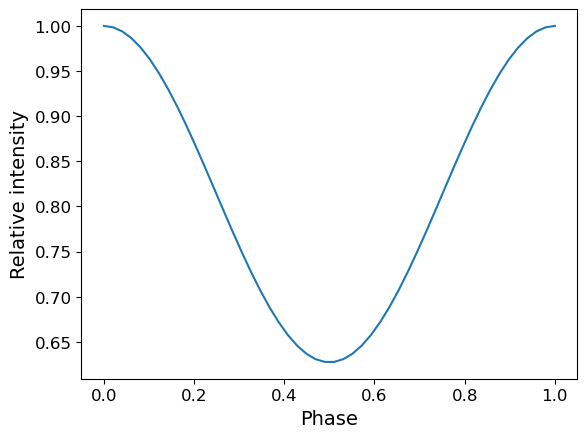

In [166]:
Rns = 10
Mns = 1.4
chivals = []
intensity=[]
phases = np.linspace (0, 2*pi, 50)

for i in range(0,3600):
    chi = round(random.uniform(0,pi),2)
    inc = round(random.uniform(0,pi),2)
    
    while [chi, inc] in chivals:
        chi = round(random.uniform(0, pi), 2)
        inc = round(random.uniform(0, pi), 2)

    chivals.append([chi, inc])
    
    intens = lightcurve (Tm, Rns, Mns, phases, chi, inc) 

    phase = np.asarray(phases) / pi / 2 
    if np.max(intens)==0:
        inten = intens
    else:
        inten = np.asarray(intens) / np.max(intens)
        
    intensity.append(inten)
    plt.plot (phase, inten) 
    plt.xlabel('Phase')
    plt.ylabel('Relative intensity')
    filename = f'lightcurve_{chi:.2f}_{inc:.2f}.png'
    filepath = os.path.join("C:/Users/Asus/Desktop/Semester II/Dissertation/samples2/", filename)
    plt.savefig(filepath)
    plt.clf()

In [108]:
data = {
    'labels': chivals,
    'Intensity': intensity
}
data = pd.DataFrame(data)
data.to_csv(".../sample.csv",index=False)
print(data)

            labels                                          Intensity
0     [1.49, 3.01]  [1.0, 0.9999591177112312, 0.9998371424011181, ...
1      [0.72, 1.5]  [1.0, 0.9957021155456541, 0.9828818461022285, ...
2      [3.0, 1.03]  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06435415...
3     [2.22, 1.04]  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4     [0.68, 0.28]  [1.0, 0.9940018361645598, 0.9760853091879931, ...
...            ...                                                ...
3595  [2.87, 1.81]  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0421900943622...
3596  [0.37, 2.12]  [1.0, 0.996181465087732, 0.9847909670963264, 0...
3597  [2.06, 1.38]  [0.039955483938567044, 0.04462178306968182, 0....
3598  [0.65, 2.68]  [1.0, 0.9982227843048371, 0.9929208541486518, ...
3599  [1.17, 1.83]  [1.0, 0.9977479751948958, 0.991029546365063, 0...

[3600 rows x 2 columns]


In [109]:
data['Intensity']=np.array(data['Intensity'])
data['Intensity']

0       [1.0, 0.9999591177112312, 0.9998371424011181, ...
1       [1.0, 0.9957021155456541, 0.9828818461022285, ...
2       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06435415...
3       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4       [1.0, 0.9940018361645598, 0.9760853091879931, ...
                              ...                        
3595    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0421900943622...
3596    [1.0, 0.996181465087732, 0.9847909670963264, 0...
3597    [0.039955483938567044, 0.04462178306968182, 0....
3598    [1.0, 0.9982227843048371, 0.9929208541486518, ...
3599    [1.0, 0.9977479751948958, 0.991029546365063, 0...
Name: Intensity, Length: 3600, dtype: object

In [110]:
train_set = data
# len(train_set)

In [8]:
train_set

,labels,Intensity
0,"[1.72, 1.26]","[0.2056011016845154, 0.2090134640004169, 0.219..."
1,"[1.63, 2.54]","[0.9403365265026199, 0.9405815663423386, 0.941..."
2,"[2.23, 0.15]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"[2.59, 1.53]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.054..."
4,"[2.85, 1.4]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...
3595,"[1.37, 0.44]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3596,"[2.2, 1.28]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.007..."
3597,"[0.14, 0.89]","[1.0, 0.994873477987754, 0.9795803275788626, 0..."
3598,"[2.67, 2.52]","[0.272697656135216, 0.27574139734985853, 0.284..."


In [111]:
torch.manual_seed(0)

validation_ratio = 0.2

val_size = int(validation_ratio * len(train_set))
train_size = len(train_set) - val_size

train_dataset, val_dataset = random_split(train_set, [train_size, val_size])

class CustomDataset(Dataset):
    def __init__(self, dataset):
        self._inputs = dataset['Intensity'].values
        self._labels = dataset['labels'].values

    def __len__(self):
        return len(self._inputs)

    def __getitem__(self, index):
        inputs = torch.tensor(self._inputs[index], dtype=torch.float32)
        labels = torch.tensor(self._labels[index], dtype=torch.float32)
        return inputs, labels

train_data = CustomDataset(train_set.iloc[train_dataset.indices])
val_data = CustomDataset(train_set.iloc[val_dataset.indices])

batch_size = 1
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)


In [117]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1,64, kernel_size=3,padding=1)
        self.pool = nn.MaxPool1d(2,2)
        self.fc1 = nn.Linear(64*25,512)        
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))      
        x = x.view(-1,64*25)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
cnn=CNN()

In [198]:
def count_parameters(model):
    total_params = 0
    for name, param in cnn.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            print(f"Layer: {name} | Number of parameters: {num_params}")
            total_params += num_params
    print(f"Total number of parameters: {total_params}")

count_parameters(model)

Layer: conv1.weight | Number of parameters: 192
Layer: conv1.bias | Number of parameters: 64
Layer: fc1.weight | Number of parameters: 819200
Layer: fc1.bias | Number of parameters: 512
Layer: fc2.weight | Number of parameters: 1024
Layer: fc2.bias | Number of parameters: 2
Total number of parameters: 820994


In [118]:
n_epochs = 25

criterion =  nn.MSELoss()
optimizer = optim.Adam(cnn.parameters(),lr=0.001)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


# Training
for epoch in range(n_epochs):
    # Training
    cnn.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:  
        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward(loss)
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)


    # Validation
    cnn.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader: 
            outputs = cnn(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{n_epochs} => "
          f"Train Loss: {avg_train_loss:.4f},"
          f"Val Loss: {avg_val_loss:.4f},")

Epoch 1/25 => Train Loss: 0.3922,Val Loss: 0.2763,
Epoch 2/25 => Train Loss: 0.3277,Val Loss: 0.3055,
Epoch 3/25 => Train Loss: 0.3164,Val Loss: 0.2933,
Epoch 4/25 => Train Loss: 0.3076,Val Loss: 0.3058,
Epoch 5/25 => Train Loss: 0.3068,Val Loss: 0.3063,
Epoch 6/25 => Train Loss: 0.3108,Val Loss: 0.3211,
Epoch 7/25 => Train Loss: 0.3047,Val Loss: 0.2863,
Epoch 8/25 => Train Loss: 0.3053,Val Loss: 0.3180,
Epoch 9/25 => Train Loss: 0.2963,Val Loss: 0.4399,
Epoch 10/25 => Train Loss: 0.3025,Val Loss: 0.2922,
Epoch 11/25 => Train Loss: 0.2968,Val Loss: 0.3091,
Epoch 12/25 => Train Loss: 0.2990,Val Loss: 0.3042,
Epoch 13/25 => Train Loss: 0.2969,Val Loss: 0.2861,
Epoch 14/25 => Train Loss: 0.2945,Val Loss: 0.3959,
Epoch 15/25 => Train Loss: 0.2927,Val Loss: 0.3938,
Epoch 16/25 => Train Loss: 0.2948,Val Loss: 0.2921,
Epoch 17/25 => Train Loss: 0.2939,Val Loss: 0.3967,
Epoch 18/25 => Train Loss: 0.2941,Val Loss: 0.2749,
Epoch 19/25 => Train Loss: 0.2922,Val Loss: 0.2962,
Epoch 20/25 => Train 

<Figure size 640x480 with 0 Axes>

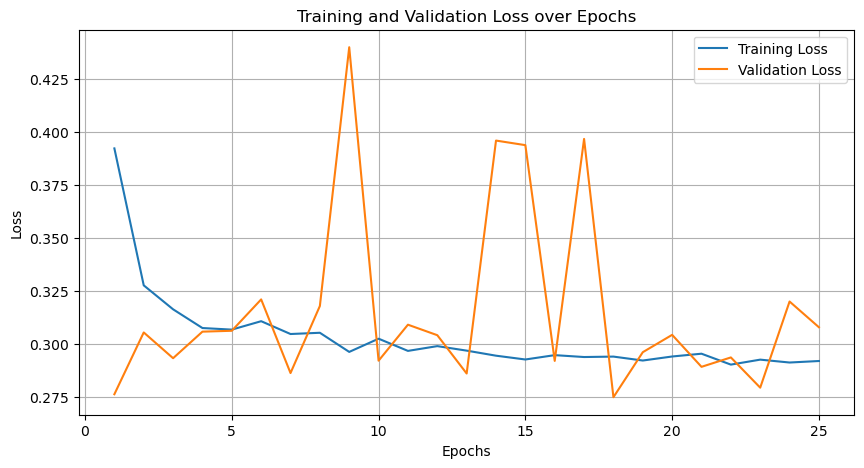

In [119]:
## plt.plot(train_losses,val_losses)
epochs = list(range(1, 26))  # Let's say we have 10 epochs
plt.clf()
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [123]:
label=[]
pred=[]
cnn.eval()
with torch.no_grad():
        for inputs, labels in val_loader: 
            outputs = cnn(inputs)
            pred.append(outputs.numpy())
            label.append(labels.numpy())
pred = np.concatenate(pred)
label = np.concatenate(label)

In [137]:
y_results=pd.DataFrame(label)
y_results.rename(columns={ 0: 'Chi Actual', 1 : 'Inc Actual'}, inplace=True)
pred=pd.DataFrame(pred)
pred.rename(columns={ 0: 'Chi Predicted CNN', 1 : 'Inc Predicted CNN'}, inplace=True)
y_results=pd.concat([y_results, pred], axis=1)
y_results

,Chi Actual,Inc Actual,Chi Predicted CNN,Inc Predicted CNN
0,3.03,1.75,2.845062,1.177784
1,0.01,2.43,0.323131,1.348308
2,2.14,0.14,1.712140,0.418693
3,1.20,0.37,1.712140,0.418693
4,0.06,0.81,0.305229,1.248769
...,...,...,...,...
715,1.55,1.42,1.446228,2.168063
716,0.66,2.95,0.669970,1.969934
717,0.18,2.05,0.310094,1.255153
718,1.82,1.83,2.446843,1.802271


Random Forest Regressor

In [126]:
from sklearn.ensemble import RandomForestRegressor

In [129]:
X = np.stack(train_set['Intensity'].apply(np.array).values)
y = np.array(train_set['labels'].tolist())

X_train, X_val = X[train_dataset.indices], X[val_dataset.indices]
y_train, y_val = y[train_dataset.indices], y[val_dataset.indices]

In [196]:
regressor = RandomForestRegressor(n_estimators=200, random_state=0, oob_score=True)

regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, oob_score=True, random_state=0)

In [197]:
from sklearn.metrics import mean_squared_error, r2_score
 
oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')
 
predictions = regressor.predict(X_val)
 
mse = mean_squared_error(y_val, predictions)
print(f'Mean Squared Error: {mse}')
 
r2 = r2_score(y_test, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.7138003042033048
Mean Squared Error: 0.27139359236073823
R-squared: -0.8052148421367985


In [138]:
predictions_results=pd.DataFrame(predictions)
predictions_results.rename(columns={ 0: 'Chi Predicted RF', 1 : 'Inc Predicted RF'}, inplace=True)
y_results=pd.concat([y_results, predictions_results], axis=1)
y_results

,Chi Actual,Inc Actual,Chi Predicted CNN,Inc Predicted CNN,Chi Predicted RF,Inc Predicted RF
0,3.03,1.75,2.845062,1.177784,2.945500,1.663000
1,0.01,2.43,0.323131,1.348308,0.435700,1.446200
2,2.14,0.14,1.712140,0.418693,1.584414,0.291707
3,1.20,0.37,1.712140,0.418693,1.584414,0.291707
4,0.06,0.81,0.305229,1.248769,0.413100,1.438700
...,...,...,...,...,...,...
715,1.55,1.42,1.446228,2.168063,0.911300,3.040400
716,0.66,2.95,0.669970,1.969934,0.848200,2.504500
717,0.18,2.05,0.310094,1.255153,0.150100,2.056300
718,1.82,1.83,2.446843,1.802271,2.241400,2.418700


In [139]:
new_order = ['Chi Actual','Chi Predicted CNN','Chi Predicted RF','Inc Actual','Inc Predicted CNN','Inc Predicted RF']
y_results = y_results.reindex(columns=new_order)
y_results

,Chi Actual,Chi Predicted CNN,Chi Predicted RF,Inc Actual,Inc Predicted CNN,Inc Predicted RF
0,3.03,2.845062,2.945500,1.75,1.177784,1.663000
1,0.01,0.323131,0.435700,2.43,1.348308,1.446200
2,2.14,1.712140,1.584414,0.14,0.418693,0.291707
3,1.20,1.712140,1.584414,0.37,0.418693,0.291707
4,0.06,0.305229,0.413100,0.81,1.248769,1.438700
...,...,...,...,...,...,...
715,1.55,1.446228,0.911300,1.42,2.168063,3.040400
716,0.66,0.669970,0.848200,2.95,1.969934,2.504500
717,0.18,0.310094,0.150100,2.05,1.255153,2.056300
718,1.82,2.446843,2.241400,1.83,1.802271,2.418700


LSTM Model

In [140]:
import tensorflow

In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [144]:
model = Sequential()
model.add(LSTM(16, input_shape = (50,1)))
model.add(Dense(16, activation='relu'))  # First additional Dense layer
model.add(Dense(2, activation='relu'))  # Second additional Dense layer

# # Output layer
# model.add(Dense(2))
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

# calling the function which define the model
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 16)                  │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,458 (5.70 KB)

 Trainable params: 1,458 (5.70 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
model.fit(X_train, y_train, epochs=10, batch_size= 1, verbose=1,  validation_data=(X_val, y_val))

Epoch 1/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step - loss: 0.6273 - val_loss: 0.2750
Epoch 2/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.2786 - val_loss: 0.2719
Epoch 3/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - loss: 0.2847 - val_loss: 0.3055
Epoch 4/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.2662 - val_loss: 0.2782
Epoch 5/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.2644 - val_loss: 0.2699
Epoch 6/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.2746 - val_loss: 0.2752
Epoch 7/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 0.2540 - val_loss: 0.2742
Epoch 8/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 0.2657 - val_loss: 0.2673
Epoch 9/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - loss: 0.2606 - val_loss: 0.2684
Epoch 10/10
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.2429 - val_loss: 0.2695


In [146]:
y_predict=model.predict(X_val)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step


In [147]:
predictions_results=pd.DataFrame(y_predict)
predictions_results.rename(columns={ 0: 'Chi Predicted LSTM', 1 : 'Inc Predicted LSTM'}, inplace=True)
y_results=pd.concat([y_results, predictions_results], axis=1)
new_order = ['Chi Actual','Chi Predicted CNN','Chi Predicted RF','Chi Predicted LSTM','Inc Actual','Inc Predicted CNN','Inc Predicted RF','Inc Predicted LSTM']
y_results = y_results.reindex(columns=new_order)
y_results

,Chi Actual,Chi Predicted CNN,Chi Predicted RF,Chi Predicted LSTM,Inc Actual,Inc Predicted CNN,Inc Predicted RF,Inc Predicted LSTM
0,3.03,2.845062,2.945500,2.543908,1.75,1.177784,1.663000,0.939081
1,0.01,0.323131,0.435700,0.385305,2.43,1.348308,1.446200,1.584128
2,2.14,1.712140,1.584414,1.574790,0.14,0.418693,0.291707,0.243469
3,1.20,1.712140,1.584414,1.574790,0.37,0.418693,0.291707,0.243469
4,0.06,0.305229,0.413100,0.341547,0.81,1.248769,1.438700,1.335836
...,...,...,...,...,...,...,...,...
715,1.55,1.446228,0.911300,1.219387,1.42,2.168063,3.040400,2.663459
716,0.66,0.669970,0.848200,0.852561,2.95,1.969934,2.504500,2.429987
717,0.18,0.310094,0.150100,0.340627,2.05,1.255153,2.056300,1.347743
718,1.82,2.446843,2.241400,2.258957,1.83,1.802271,2.418700,2.063334


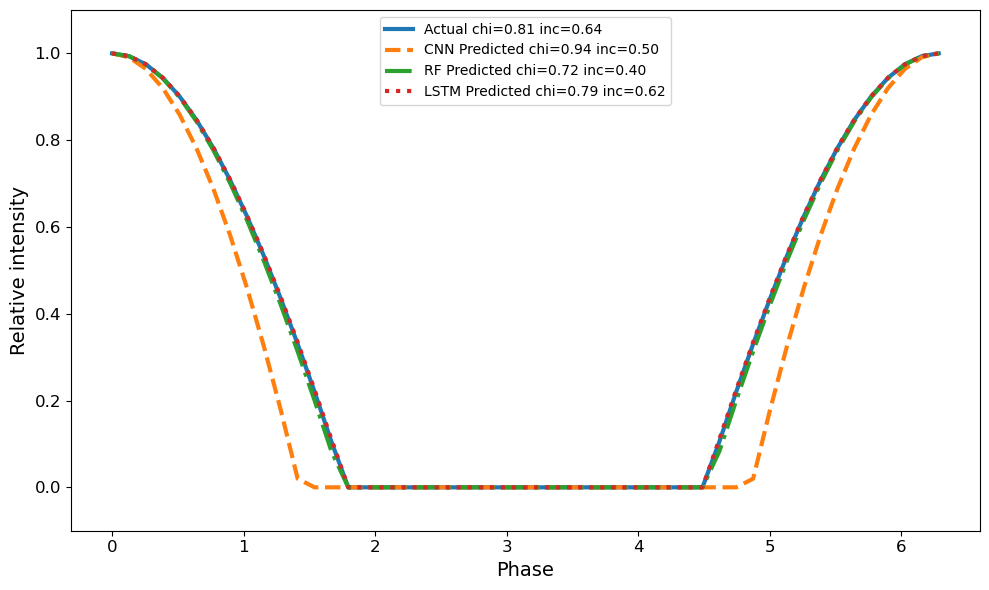

In [193]:
instance_idx = random.randint(0, 720)

def plot_lightcurves(data,instance_idx):
    chi_actual = data['Chi Actual'][instance_idx]
    inc_actual = data['Inc Actual'][instance_idx]
    chi_pred_cnn = data['Chi Predicted CNN'][instance_idx]        
    inc_pred_cnn = data['Inc Predicted CNN'][instance_idx]
    chi_pred_rf = data['Chi Predicted RF'][instance_idx]
    inc_pred_rf = data['Inc Predicted RF'][instance_idx]
    chi_pred_lstm = data['Chi Predicted LSTM'][instance_idx]
    inc_pred_lstm = data['Inc Predicted LSTM'][instance_idx]
        
        # Compute light curves
    intens_actual = lightcurve(Tm, Rns, Mns, phases, chi_actual, inc_actual)
    intens_pred_cnn = lightcurve(Tm, Rns, Mns, phases, chi_pred_cnn, inc_pred_cnn)
    intens_pred_rf = lightcurve(Tm, Rns, Mns, phases, chi_pred_rf, inc_pred_rf)
    intens_pred_lstm = lightcurve(Tm, Rns, Mns, phases, chi_pred_lstm, inc_pred_lstm)
        
    inten_actual = intens_actual / np.max(intens_actual) if np.max(intens_actual) != 0 else intens_actual
    inten_pred_cnn = intens_pred_cnn / np.max(intens_pred_cnn) if np.max(intens_pred_cnn) != 0 else intens_pred_cnn
    inten_pred_rf = intens_pred_rf / np.max(intens_pred_rf) if np.max(intens_pred_rf) != 0 else intens_pred_rf
    inten_pred_lstm = intens_pred_lstm / np.max(intens_pred_lstm) if np.max(intens_pred_lstm) != 0 else intens_pred_lstm
        
        # Plot in respective subplot
    plt.figure(figsize=(10, 6))

    plt.plot(phases, inten_actual, label=f'Actual chi={chi_actual:.2f} inc={inc_actual:.2f}', linestyle='-', linewidth=3)
    plt.plot(phases, inten_pred_cnn, label=f'CNN Predicted chi={chi_pred_cnn:.2f} inc={inc_pred_cnn:.2f}', linestyle='--', linewidth=3)
    plt.plot(phases, inten_pred_rf, label=f'RF Predicted chi={chi_pred_rf:.2f} inc={inc_pred_rf:.2f}', linestyle='-.', linewidth=3)
    plt.plot(phases, inten_pred_lstm, label=f'LSTM Predicted chi={chi_pred_lstm:.2f} inc={inc_pred_lstm:.2f}', linestyle=':', linewidth=3)

    plt.xlabel('Phase', fontsize=14)
    plt.ylabel('Relative intensity', fontsize=14)
    plt.tick_params(axis='x', labelsize=12)  
    plt.tick_params(axis='y', labelsize=12)
    plt.ylim(-0.1, 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_lightcurves(y_results,instance_idx)